In [1]:
import numpy as np
import xarray as xr


from pyrte_rrtmgp.rrtmgp.data_files import (
    CloudOpticsFiles,
    GasOpticsFiles,
)
# from pyrte_rrtmgp.examples import (
#     compute_RCE_clouds,
#     compute_RCE_profiles,
#     load_example_file,
#     ALLSKY_EXAMPLES,
# )
from pyrte_rrtmgp import rte
from pyrte_rrtmgp.rrtmgp import GasOptics, CloudOptics

# I need Ozone statistics - I try to obtain it from the RCEMIP data
from pyrte_rrtmgp.examples import RFMIP_FILES, load_example_file


load profiles

In [2]:
min_hgt = 40.

level2_path = "/work/mh1498/m301248/TCO_data/eurec4a_profiles_level2/EUREC4A_BCO_Vaisala-RS_L2_v3.0.0.nc"
ds_eureca = xr.open_dataset(level2_path)
ds_eureca_bco = ds_eureca.where(((ds_eureca["platform"] == 1)&(ds_eureca["ascent_flag"]==1)&(ds_eureca.alt>min_hgt)), drop=True)
## renaming for common ground
ds_eureca_bco = ds_eureca_bco.swap_dims({"sounding": "launch_time"})
ds_eureca_bco = ds_eureca_bco.rename({"alt":"height"})

ds_eureca_bco_rad = ds_eureca_bco.copy().rename({"launch_time":"column"})
ds_eureca_bco_rad = ds_eureca_bco_rad.rename({"height":"level"}).drop_vars(["sounding", "flight_time", "lat", "lon"])


ds_orcestra = xr.open_dataset("ipfs://bafybeid7cnw62zmzfgxcvc6q6fa267a7ivk2wcchbmkoyk4kdi5z2yj2w4", engine="zarr")
ds_orcestra_bco = ds_orcestra.where(((ds_orcestra["platform"] == "BCO")&(ds_orcestra["ascent_flag"]==0)&(ds_orcestra.height>min_hgt)), drop=True)
ds_orcestra_bco_rad = ds_orcestra_bco.copy().rename({"height":"level"})
ds_orcestra_bco_rad = ds_orcestra_bco_rad.rename({"launch_time":"column"}).drop_vars(["interpolated_time", "lat", "lon"])



In [3]:
ingr_eu = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/EUREC4A_IngrFlux.nc")
sst_eu = ingr_eu.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell"]).rename({"time":"column"}).drop_vars("alt")

ingr_or = xr.open_dataset("/work/mh1498/m301248/TCO_data/fluxes_data/ORCESTRA_IngrFlux.nc")
sst_or = ingr_or.sst.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell"]).rename({"time":"column"}).drop_vars("alt")

In [6]:
def make_atmosphere(radiosounding, sst_in):
    "radiosounding should have dimensions:"
    "- column : aka time"
    "- level : actual recording height of the sonde"

    "sst should have dimension column instead of time"

    ## broadcast sst to be the same 
    ## for every day of the radiosoundings
    rs_dates = radiosounding.column.dt.floor("D")
    sst_dates = sst_in.column.dt.floor("D")

    # Keep only days present in both
    common_days = np.intersect1d(rs_dates.values, sst_dates.values)

    rs = radiosounding.sel(column=rs_dates.isin(common_days))
    sst = sst_in.sel(column=sst_dates.isin(common_days))

    # Create a daily SST lookup
    sst_daily = (
    sst.assign_coords(day=sst.column.dt.floor("D"))
       .swap_dims({"column": "day"})
       .drop_vars("column")
)

    sfc_temp = sst_daily.reindex(day=rs.column.dt.floor("D").values)
    sfc_temp = sfc_temp.rename(day="column")
    sfc_temp = sfc_temp.assign_coords(column=rs.column)

    sfc_temp.name = "surface_temperature"

    ## compute the other variables Im interested in
    t, p, q = rs.ta, rs.p, rs.q
    t.name, p.name = "temp_level", "pres_level"

    t_layer = xr.DataArray(
    0.5 * (t.data[:, :-1] + t.data[:, 1:]),
    dims=("column", "layer"),
    coords={
        "column": t.column,
        "layer": 0.5 * (t.level.data[:-1] + t.level.data[1:]),
    },
    name="temp_layer",
    )

    p_layer = xr.DataArray(
        0.5 * (p.data[:, :-1] + p.data[:, 1:]),
        dims=("column", "layer"),
        coords={
            "column": p.column,
            "layer": 0.5 * (p.level.data[:-1] + p.level.data[1:]),
        },
        name="temp_layer",
    )

    q_layer = xr.DataArray(
        0.5 * (q.data[:, :-1] + q.data[:, 1:]),
        dims=("column", "layer"),
        coords={
            "column": q.column,
            "layer": 0.5 * (q.level.data[:-1] + q.level.data[1:]),
        },
        name="temp_layer",
    )

    t_layer.name, p_layer.name, q_layer.name = "temp_layer", "pres_layer", "h2o"


    atmosphere = xr.Dataset(
        data_vars={
            "temp_level": t,
            "pres_level": p,
            "temp_layer": t_layer,
            "pres_layer": p_layer,
            "h2o": q_layer,
            "surface_temperature": sfc_temp,
        }
    )


    # Add other gas values
    gas_values = {
        "co2": 348e-6,
        "ch4": 1650e-9,
        "n2o": 306e-9,
        "n2": 0.7808,
        "o2": 0.2095,
        "co": 0.0,
    }

    for gas_name, value in gas_values.items():
        atmosphere[gas_name] = value

    return atmosphere

In [7]:
atmosphere = make_atmosphere(ds_orcestra_bco_rad, sst_or)
atmosphere

<xarray.Dataset> Size: 9MB
Dimensions:              (level: 3095, column: 141, layer: 3094)
Coordinates:
  * level                (level) float32 12kB 50.0 60.0 ... 3.098e+04 3.099e+04
  * column               (column) datetime64[ns] 1kB 2024-09-07T01:05:09.9399...
  * layer                (layer) float32 12kB 55.0 65.0 ... 3.098e+04 3.098e+04
Data variables:
    temp_level           (column, level) float32 2MB 299.8 300.3 ... nan nan
    pres_level           (column, level) float32 2MB 1.006e+05 1.005e+05 ... nan
    temp_layer           (column, layer) float32 2MB 300.1 300.4 ... nan nan
    pres_layer           (column, layer) float32 2MB 1.005e+05 1.004e+05 ... nan
    h2o                  (column, layer) float32 2MB 0.01864 0.01855 ... nan nan
    surface_temperature  (column) float64 1kB 303.5 303.5 303.5 ... 303.5 303.5
    co2                  float64 8B 0.000348
    ch4                  float64 8B 1.65e-06
    n2o                  float64 8B 3.06e-07
    n2                   float64 8B 0.7808
    o2                   float64 8B 0.2095
    co                   float64 8B 0.0

build a ozone profile starting from the RCEMIP examples offered here

(10000.0, 0.0)

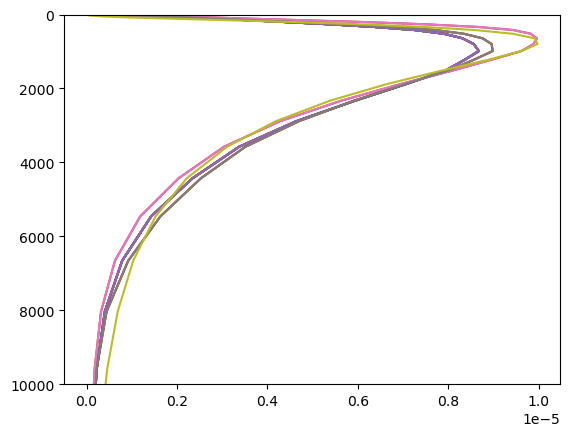

In [32]:
atmosphere_ozone = load_example_file(RFMIP_FILES.ATMOSPHERE)
ozone = atmosphere_ozone.ozone

import matplotlib.pyplot as plt
o3 = ozone.isel(site=0)
pr = atmosphere_ozone.pres_layer.isel(site=0)

for i in range(18):
    plt.plot(o3.isel(expt=i), pr)

o3_fit = 1e-5 * np.exp( -(np.log10(pr) - 2.87 )**2 / (2*0.2) )
plt.plot( o3_fit, pr )

plt.gca().invert_yaxis()
# plt.yscale('log')
plt.ylim(100e2, 0)

In [9]:
print(f"minimum pressure reached during eureca = {ds_eureca_bco_rad.p.min().item()}" )
print(f"minimum pressure reached during orcestra = {ds_orcestra_bco_rad.p.min().item()}" )

minimum pressure reached during eureca = 1822.0308837890625
minimum pressure reached during orcestra = 1469.4886474609375


In [10]:
o3.isel(expt=0)

<xarray.DataArray 'ozone' (layer: 60)> Size: 240B
array([4.4735717e-07, 1.1235722e-06, 1.6883033e-06, 2.2604422e-06,
       2.8879581e-06, 3.6122970e-06, 4.4468311e-06, 5.3930712e-06,
       6.3562070e-06, 7.2482549e-06, 7.8990524e-06, 8.3167697e-06,
       8.5618030e-06, 8.6748123e-06, 8.3630330e-06, 7.9319598e-06,
       7.0663455e-06, 5.9390818e-06, 4.6349483e-06, 3.3730328e-06,
       2.3400678e-06, 1.4257654e-06, 7.8535692e-07, 4.0271973e-07,
       2.2289753e-07, 1.3767226e-07, 9.7431609e-08, 8.1588070e-08,
       7.4955771e-08, 7.1354016e-08, 6.9397935e-08, 6.7553962e-08,
       6.5802979e-08, 6.4040194e-08, 6.2560844e-08, 6.1051310e-08,
       5.9536784e-08, 5.7725881e-08, 5.5735939e-08, 5.3874253e-08,
       5.1729117e-08, 4.9145282e-08, 4.6604050e-08, 4.4161602e-08,
       4.2340243e-08, 4.0812498e-08, 3.9909896e-08, 3.9134882e-08,
       3.8560565e-08, 3.8031210e-08, 3.7531716e-08, 3.7075470e-08,
       3.6565165e-08, 3.5557488e-08, 3.4713466e-08, 3.4027039e-08,
       3.3488234e-08, 3.3082873e-08, 3.2792201e-08, 3.2489542e-08],
      dtype=float32)
Dimensions without coordinates: layer
Attributes:
    standard_name:  mole_fraction_of_ozone_in_air
    units:          1
    coordinates:    lon lat time
    long_name:      O3 mole fraction

compute gas optics

In [13]:
gas_optics_lw = GasOptics(
    gas_optics_file=GasOpticsFiles.LW_G256
)

gas_optics_sw = GasOptics(
    gas_optics_file=GasOpticsFiles.SW_G224
)

In [27]:
gas_optics_lw.required_gases


{'co', 'co2', 'h2o', 'n2o', 'o2', 'o3'}

In [21]:
atmosphere = atmosphere.transpose("column", "layer", "level")
atmosphere

<xarray.Dataset> Size: 9MB
Dimensions:              (level: 3095, column: 141, layer: 3094)
Coordinates:
  * level                (level) float32 12kB 50.0 60.0 ... 3.098e+04 3.099e+04
  * column               (column) datetime64[ns] 1kB 2024-09-07T01:05:09.9399...
  * layer                (layer) float32 12kB 55.0 65.0 ... 3.098e+04 3.098e+04
Data variables: (12/13)
    temp_level           (column, level) float32 2MB 299.8 300.3 ... nan nan
    pres_level           (column, level) float32 2MB 1.006e+05 1.005e+05 ... nan
    temp_layer           (column, layer) float32 2MB 300.1 300.4 ... nan nan
    pres_layer           (column, layer) float32 2MB 1.005e+05 1.004e+05 ... nan
    h2o                  (column, layer) float32 2MB 0.01864 0.01855 ... nan nan
    surface_temperature  (column) float64 1kB 303.5 303.5 303.5 ... 303.5 303.5
    ...                   ...
    ch4                  float64 8B 1.65e-06
    n2o                  float64 8B 3.06e-07
    n2                   float64 8B 0.7808
    o2                   float64 8B 0.2095
    co                   float64 8B 0.0
    o3                   float64 8B 0.0

In [22]:
optical_props_lw = gas_optics_lw.compute(
    atmosphere, 
    add_to_input=False,
)
optical_props_lw["surface_emissivity"] = 0.98
optical_props_lw

ValueError: cannot reshape array of size 0 into shape (9,0,newaxis)

In [ ]:
optical_props_sw = gas_optics_sw.compute(
    atmosphere, 
    add_to_input=False,
)
optical_props_sw["surface_albedo_direct"] = 0.06
optical_props_sw["surface_albedo_diffuse"] = 0.06
# Could also specific a single "surface_albedo"
optical_props_sw["mu0"] = 0.86
optical_props_sw

compute fluxes

fluxes = optical_props.rte.solve(add_to_input=False)
fluxes